# Fleet Observability & Incident Root Cause Analysis (RCA)

This notebook contains the data analysis and root cause investigation for the Ati Motors AMR fleet operational incident on June 30, 2026, between 10:00 AM and 11:00 AM.

## 1. Setup and Libraries
We load standard packages and configure Matplotlib and Seaborn for plotting.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["font.size"] = 10

colors = {
    "Robot_01": "#1f77b4",
    "Robot_02": "#ff7f0e",
    "Robot_03": "#2ca02c",
    "Robot_04": "#d62728"
}

## 2. Load Data
We load the telemetry and trip databases.

In [12]:
from IPython.display import display

telemetry = pd.read_csv("fleet_observability_assignment/telemetry.csv")
trips = pd.read_csv("fleet_observability_assignment/trips.csv")

print("Telemetry Records (Head):")
display(telemetry.head())

print("\nTrip Records:")
display(trips)

## 3. Log Exploration & Programmatic Duplicate Check
We read the operational log file `events.log` and programmatically identify duplicate log entries.

In [4]:

# main objective of this cell is:  Before trusting the logs for incident investigation, I wanted to verify whether the logging data itself was reliable.

with open("fleet_observability_assignment/events.log", "r") as f:
    lines = [line.strip() for line in f if line.strip()]

line_counts = Counter(lines)
duplicates = {line: count for line, count in line_counts.items() if count > 1}

print("Duplicate log entries found:")
for line, count in duplicates.items():
    print(f"  '{line}' appears {count} times")

Duplicate log entries found:
  '10:15:00 Robot_02 TripStarted T102' appears 2 times


## 4. Telemetry Data Quality Check
We examine the `trip_id` column inside `telemetry.csv` to verify its reliability.

main objective ye h ki:  The objective of this cell was to validate whether the telemetry trip_id could be trusted for analysis. After identifying that the same trip ID was shared by multiple robots simultaneously, I treated it as a data quality issue and decided to reconstruct trip mapping using time-window logic instead


In [11]:
print("Unique trip IDs per timestamp in telemetry (first 5 groups):")
display(telemetry.groupby("timestamp")["trip_id"].unique().head(5))

print("\nRobots sharing a telemetry trip_id simultaneously:")
print(telemetry.groupby(["timestamp", "trip_id"])["robot_id"].count().unique())

Unique trip IDs per timestamp in telemetry (first 5 groups):


timestamp
2026-06-30 10:00:00    [T100]
2026-06-30 10:02:00    [T101]
2026-06-30 10:04:00    [T102]
2026-06-30 10:06:00    [T103]
2026-06-30 10:08:00    [T104]
Name: trip_id, dtype: object


Robots sharing a telemetry trip_id simultaneously:
[4]


## 5. Chronological Data Merging
We perform a conditional time-window merge to map each telemetry poll to its corresponding active trip window from `trips.csv`.

In [6]:
# preprocessing steps.

# 1. first, I converted all timestamps into a common datetime format
telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"]) 

trips_clean = trips.copy()
# 2. Second, the trips dataset contained only time values, so I added the incident date (30 June 2026) to create complete timestamps.
trips_clean["start_dt"] = pd.to_datetime("2026-06-30 " + trips_clean["trip_start"])

# 3. Third, for trips with a missing trip_end value, I temporarily used the end of the investigation window (11:00 AM) only for matching purposes.
trips_clean["end_dt"] = pd.to_datetime("2026-06-30 " + trips_clean["trip_end"].fillna("11:00:00"))

# trip_id problem solve
def match_trip(row):
    match = trips_clean[
        (trips_clean["robot_id"] == row["robot_id"]) &
        (row["timestamp"] >= trips_clean["start_dt"]) &
        (row["timestamp"] <= trips_clean["end_dt"])
    ]
    if not match.empty:
        return match.iloc[0]["trip_id"]
    return None

telemetry["actual_trip_id"] = telemetry.apply(match_trip, axis=1)

print("Sample of telemetry data with corrected actual trip associations:")
display(telemetry[telemetry["actual_trip_id"].notna()].head())

Sample of telemetry data with corrected actual trip associations:


,timestamp,robot_id,battery_level,cpu_usage,network_latency_ms,position_x,position_y,trip_id,actual_trip_id
12,2026-06-30 10:06:00,Robot_01,76,43,133,20,32,T103,T101
33,2026-06-30 10:16:00,Robot_02,65,38,159,5,12,T108,T102
37,2026-06-30 10:18:00,Robot_02,63,36,165,31,34,T109,T102
38,2026-06-30 10:18:00,Robot_03,53,36,171,999,999,T109,T204
41,2026-06-30 10:20:00,Robot_02,64,57,99,22,22,T110,T102


## 6. Visualizations & Anomaly Detection
We plot network latency, CPU usage, battery charge, and spatial coordinates to identify fleet anomalies.

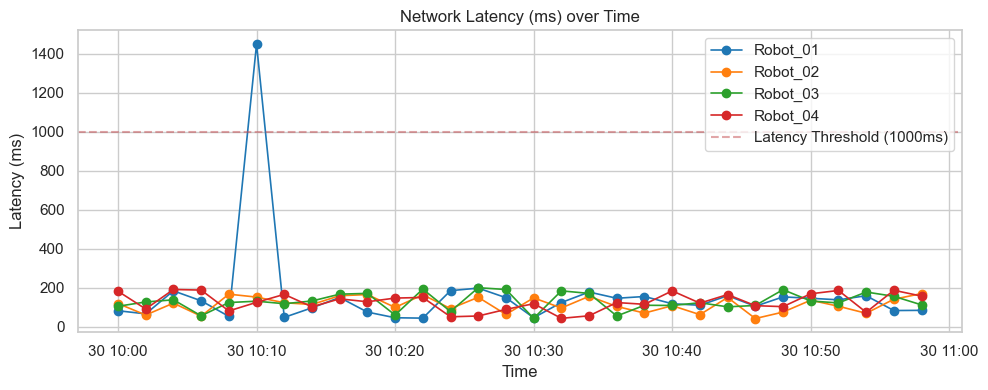

In [7]:
plt.figure(figsize=(10, 4)) # ye canvas ka size bata rha h.
for r_id, group in telemetry.groupby("robot_id"):
    plt.plot(group["timestamp"], group["network_latency_ms"], label=r_id, marker='o', color=colors[r_id], linewidth=1.2)
    # ab hmne 1000 ms pr ek line bana di ab iske uper jitne bhi honge netowork sb abnormal mein count honge.
plt.axhline(y=1000, color='r', linestyle='--', alpha=0.5, label="Latency Threshold (1000ms)")
plt.title("Network Latency (ms) over Time")
plt.xlabel("Time")
plt.ylabel("Latency (ms)")
plt.legend()
plt.tight_layout() # margin ko shi se adjust krne ke liye.
plt.show()

Robot_01 telemetry captured 1450ms at 10:10:00. This aligns with the real-time event log entry at 10:06:10 — the telemetry's 2-minute polling interval means the spike (which began before 10:06:10) was captured in the next scheduled snapshot.

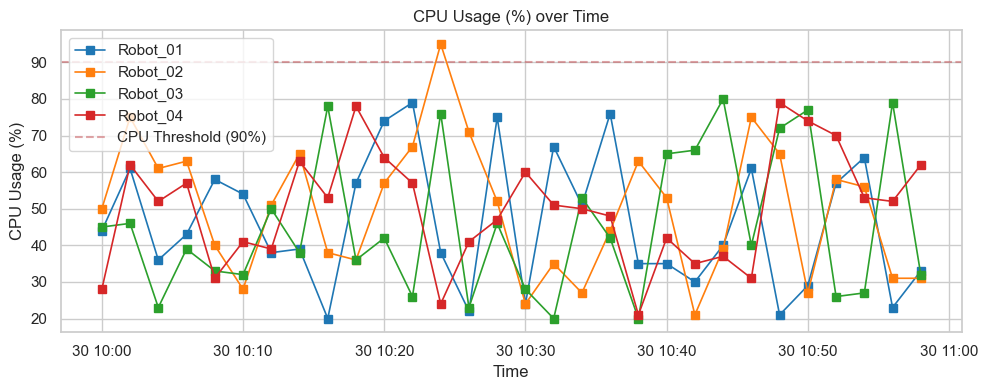

In [8]:
plt.figure(figsize=(10, 4))
for r_id, group in telemetry.groupby("robot_id"):
    plt.plot(group["timestamp"], group["cpu_usage"], label=r_id, marker='s', color=colors[r_id], linewidth=1.2)
plt.axhline(y=90, color='r', linestyle='--', alpha=0.5, label="CPU Threshold (90%)")
plt.title("CPU Usage (%) over Time")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.tight_layout()
plt.show()

Robot_02 telemetry captured 95% CPU usage at 10:24:00. This aligns with the real-time event log entry at 10:21:30 — the telemetry's 2-minute polling interval means the CPU spike (which began before 10:21:30) was captured in the next scheduled snapshot.

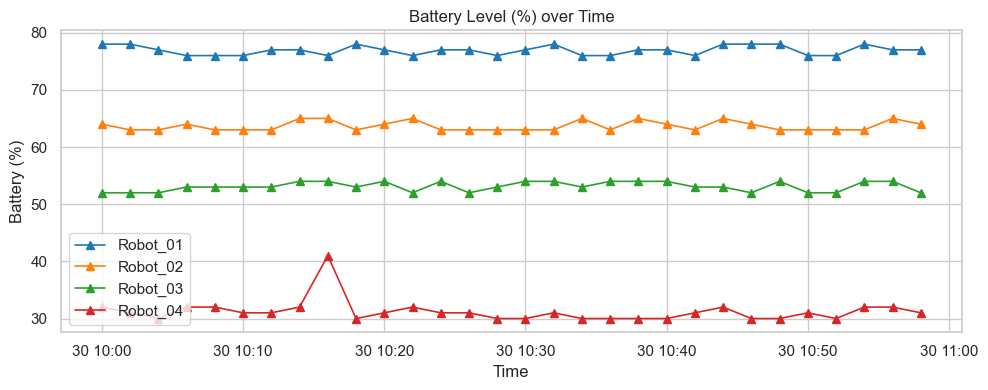

In [9]:
plt.figure(figsize=(10, 4))
for r_id, group in telemetry.groupby("robot_id"):
    plt.plot(group["timestamp"], group["battery_level"], label=r_id, marker='^', color=colors[r_id], linewidth=1.2)
plt.title("Battery Level (%) over Time")
plt.xlabel("Time")
plt.ylabel("Battery (%)")
plt.legend()
plt.tight_layout()
plt.show()

Note: here the event log entry (10:44:00) is 28 minutes AFTER the telemetry captured the jump (10:16:00) — opposite pattern from above. This could indicate the log was queued/delayed on this specific robot.

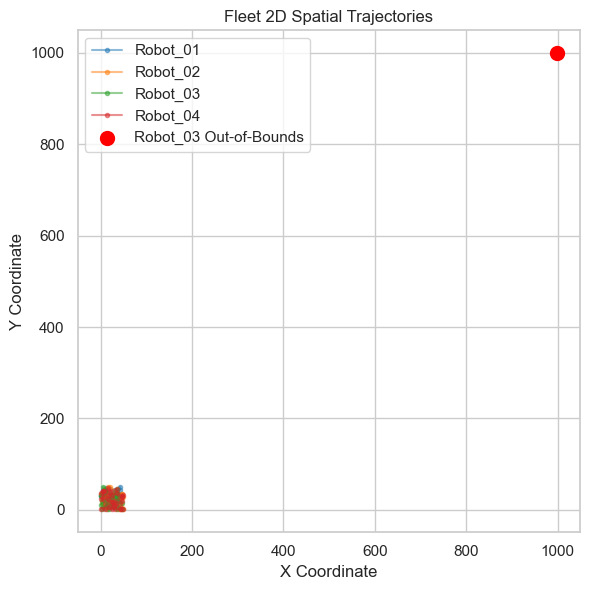

In [10]:
plt.figure(figsize=(6, 6))
for r_id, group in telemetry.groupby("robot_id"):
    valid = group[(group["position_x"] < 100) & (group["position_y"] < 100)]
    plt.plot(valid["position_x"], valid["position_y"], label=r_id, marker='o', markersize=3, color=colors[r_id], alpha=0.5)

plt.scatter([999], [999], color='red', s=100, label="Robot_03 Out-of-Bounds")
plt.title("Fleet 2D Spatial Trajectories")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.tight_layout()
plt.show()

Robot_03 position coordinates recorded an out-of-bounds coordinate jump of (999, 999) at 10:18:00, which aligns with the log event at 10:18:05.

## 7. Table of Identified Fleet Anomalies

| Anomaly Type | Robot ID | Category | Finding | Reason | Impact |
|---|---|---|---|---|---|
| Latency Spike | Robot_01 | **Network** | 1450ms at 10:10:00 | Avg ~130ms | Trip cancellation |
| False Battery Warning | Robot_01 | **System/Software** | Warning at 76% battery | False trigger | No real impact |
| CPU Spike | Robot_02 | **Robot Behavior** | 95% at 10:24:00 | Exceeds 30-70% norm | Temporary overload |
| Position Jump | Robot_03 | **Robot Behavior** (sensor) | (999,999) | Outside 0-50 range | GPS glitch |
| Battery Jump | Robot_04 | **Robot Behavior** (sensor) | +9% no charge | Physically impossible | Calibration issue |
| Stuck Trip | Robot_04 | **System/Software** | No completion event | Trip left open | DB integrity risk |
| Duplicate Log | Robot_02 | **System/Software** | TripStarted logged twice | Redundant write | Logging bug |

## 8. Incident Chronological Timeline (10:00 AM - 11:00 AM)

- **10:00:00**: Fleet monitoring begins.
- **10:05:12**: **Robot_01** starts trip `T101` from A to B.
- **10:05:14**: **Robot_01** successfully acquires spatial lock for `Zone_A`.
- **10:05:55**: **Robot_01** triggers a `BatteryLowWarning` (false alarm, battery is at 76%).
- **10:06:10**: **Robot_01** experiences a massive **Network Latency Spike (1450ms)**.
- **10:06:18**: Due to high latency, **Robot_01** fails to communicate with the lock manager to acquire the lock for `Zone_B` within the safety timeout period, triggering `ResourceLockTimeout Zone_B`.
- **10:06:20**: Lacking the spatial lock to enter Zone_B and experiencing bad connection, **Robot_01** cancels its trip `T101` (status: `cancelled`).
- **10:15:00**: **Robot_02** starts trip `T102` (duplicate log entries recorded in events.log).
- **10:16:00**: **Robot_04** battery charge jumps from 32% to 41% (shows in events.log at 10:44:00 due to local queue lag).
- **10:17:40**: **Robot_03** starts trip `T204`.
- **10:17:42**: **Robot_03** acquires lock for Zone_C.
- **10:18:00**: **Robot_03** telemetry records out-of-bounds coordinates `(999, 999)`.
- **10:18:05**: **Robot_03** log records `PositionJumpDetected`.
- **10:18:15**: **Robot_03** successfully completes trip `T204`.
- **10:21:30**: **Robot_02** experiences CPU High 95% (shows in telemetry at 10:24:00 due to periodic 2-minute polling delay).
- **10:25:00**: **Robot_02** successfully completes trip `T102`.
- **10:40:00**: **Robot_04** starts trip `T301` from M to N.
- **10:58:00**: Fleet monitoring ends. Robot_04's trip remains in a running state.

## 9. Root Cause Analysis (RCA) & Conclusions

### Most Critically Affected Robot
**Robot_01** was the most critically affected robot. It is the only vehicle whose trip aborted and was cancelled due to system failure. The other robots completed their trips successfully (Robot_02 and Robot_03)

### Root Cause Determination
The primary root cause of the incident is **Network Conditions** (specifically the **1450ms network latency spike**).

**Evaluation of Categories**:

1. Network Conditions (Accepted):
Robot_01 experienced a 1450 ms network latency spike, followed by a ResourceLockTimeout Zone_B event and trip cancellation. The high latency likely delayed communication with the fleet controller, causing the trip to be aborted as a safety measure.

2. Robot Behavior (Rejected):
Robot_03's (999,999) position jump and Robot_04's 9% battery increase were abnormal, but neither caused a trip failure. These appear to be sensor or telemetry issues rather than the main cause of the incident.

3. System Behavior (Rejected):
Robot_02 reached 95% CPU usage, and duplicate log entries were found. However, Robot_02 still completed trip T102, so these issues did not directly lead to the operational failure.

5 out of 7 anomalies are Robot Behavior or System-related, but only the Network latency anomaly directly correlates with the actual failure (trip cancellation), which is why Network Conditions is identified as the primary root cause.

## 10. Assumptions

1. The incident date was assumed to be 30 June 2026 so that the trip_start and trip_end times could be converted into complete timestamps.
2. Robot_04's trip (T301) does not have a recorded trip_end. For merging purposes, 11:00:00 (the end of the investigation window) was used as a placeholder. This does not mean the trip actually ended at that time.
3. When a log event and a telemetry reading did not have the exact same timestamp (for example, BatteryLowWarning at 10:05:55), the nearest telemetry sample (10:06:00) was used for comparison.
4. The trip_id column in telemetry.csv was found to be unreliable, so it was not used for the analysis. Instead, the correct trip was reconstructed using the trip start and end times.

# Task Answers

Given Task Answers: 


1.(a): 

What happened between 10:00–11:00? 


Ans: Between 10:00 AM and 11:00 AM, multiple operational anomalies were observed across the fleet. Robot_01 experienced a severe network latency spike followed by a trip cancellation. Robot_02 experienced a high CPU spike but successfully completed its trip. Robot_03 showed an impossible position jump but still completed its task. Robot_04 exhibited a battery anomaly and its trip remained in the running state without proper completion.

1.(b).Which robot faced the most critical issue? 

Ans: Robot_01 
Evidence: 
Network latency = 1450 ms, 
Log shows NetworkLatencyHigh, 
Trip cancelled

1.(c): What was the likely sequence of events?

Ans: 10:05:12
Robot_01 starts trip

↓

10:05:55
Battery warning

↓

10:06:10
Network latency high (log)

↓

10:10:00
Telemetry captures 1450 ms latency

↓

Resource lock timeout

↓

Trip cancelled

## Task 2 : Identify at least 5 anomalies

Ans: Anomaly 1
What?

Network Latency Spike

Robot_01

1450 ms

Why abnormal?

Normal latency ~100–200 ms hoti hai.

1450 ms bahut high hai.

Operational Impact

Communication delay

↓

Timeout

↓

Trip Cancelled

Anomaly 2
What?

CPU Spike

Robot_02

95%

Why abnormal?

CPU threshold cross.

Operational Impact

Performance degrade ho sakti hai.

Lekin trip complete hui.

Anomaly 3
What?

Position Jump

Robot_03

(999,999)

Why abnormal?

Warehouse boundaries ke bahar.

Impossible coordinate.

Operational Impact

Localization / GPS issue.

Anomaly 4
What?

Battery Jump

Robot_04

32%

↓

41%

Why abnormal?

Charging ke bina battery increase nahi hoti.

Operational Impact

Sensor error ya telemetry inconsistency.

Anomaly 5
What?

Duplicate Logs

Why abnormal?

Same event multiple baar.

Operational Impact

False alert / Incorrect monitoring.


## Task. 3

Q1: What is the most likely Root Cause?

Ans: Network Condition,  
Specifically,  
Network Latency Spike  -> kyu ki iski wajah se trip canceled hui thi

Q2: Was it primarily due to robot behavior, system behavior, or network conditions? 

Ans: Network Condition

Q3: What evidence supports your conclusion? 
Ans: Notebook ke multiple sections se evidence aata hai.

Network Graph

↓

1450 ms

Event Log

↓

NetworkLatencyHigh

Timeline

↓

Latency

↓

Timeout

↓

Cancellation

Trip Status

↓

Cancelled

Ye 4 evidence milkar Root Cause prove karte hain.

# Task 4: Bonus Anomalies

Ans: 

One important issue I found was that the telemetry trip_id column was unreliable. The same trip ID appeared simultaneously for multiple robots, which violates the business rule that one trip belongs to one robot. Because of this, I did not use the telemetry trip ID directly. Instead, I reconstructed the correct trip mapping using the trip start and end times. This mattered because using incorrect trip IDs would have produced an incorrect incident timeline and root cause analysis